In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

# Generate synthetic data
torch.manual_seed(0)
X = torch.rand(100, 2)  # 100 samples with 2 features each
y = (X[:, 0] + X[:, 1] > 1).float().unsqueeze(1)  # Class 1 if sum of features > 1, else Class 0

# Split into training and testing
train_size = int(0.8 * len(X))
test_size = len(X) - train_size
train_dataset = TensorDataset(X[:train_size], y[:train_size])
test_dataset = TensorDataset(X[train_size:], y[train_size:])

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

In [2]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 2)  # 2 input features, 2 hidden nodes
        self.fc2 = nn.Linear(2, 1)  # 2 hidden nodes, 1 output node (binary classification)
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation for binary classification

    def forward(self, x):
        x = self.fc1(x)
        x = self.sigmoid(x)  # Activation for hidden layer
        x = self.fc2(x)
        x = self.sigmoid(x)  # Activation for output layer
        return x

# Initialize the network
model = SimpleNN()

# Define loss and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Training loop
def train(model, loader):
    model.train()
    for epoch in range(1000):  # Train for 100 epochs
        for data, target in loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/1000], Loss: {loss.item():.4f}')

train(model, train_loader)

# Testing the network
def test(model, loader):
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for data, target in loader:
            output = model(data)
            predicted = (output > 0.5).float()
            total += target.size(0)
            correct += (predicted == target).sum().item()

    print(f'Accuracy: {100 * correct / total:.2f}%')

test(model, test_loader)

Epoch [10/1000], Loss: 0.7028
Epoch [20/1000], Loss: 0.6625
Epoch [30/1000], Loss: 0.6983
Epoch [40/1000], Loss: 0.6723
Epoch [50/1000], Loss: 0.7163
Epoch [60/1000], Loss: 0.6412
Epoch [70/1000], Loss: 0.6544
Epoch [80/1000], Loss: 0.6644
Epoch [90/1000], Loss: 0.6177
Epoch [100/1000], Loss: 0.5837
Epoch [110/1000], Loss: 0.6478
Epoch [120/1000], Loss: 0.5399
Epoch [130/1000], Loss: 0.5200
Epoch [140/1000], Loss: 0.5004
Epoch [150/1000], Loss: 0.5176
Epoch [160/1000], Loss: 0.4653
Epoch [170/1000], Loss: 0.3748
Epoch [180/1000], Loss: 0.3761
Epoch [190/1000], Loss: 0.3176
Epoch [200/1000], Loss: 0.2721
Epoch [210/1000], Loss: 0.3223
Epoch [220/1000], Loss: 0.2600
Epoch [230/1000], Loss: 0.4134
Epoch [240/1000], Loss: 0.2500
Epoch [250/1000], Loss: 0.1577
Epoch [260/1000], Loss: 0.1974
Epoch [270/1000], Loss: 0.1885
Epoch [280/1000], Loss: 0.1239
Epoch [290/1000], Loss: 0.1962
Epoch [300/1000], Loss: 0.1861
Epoch [310/1000], Loss: 0.2188
Epoch [320/1000], Loss: 0.2070
Epoch [330/1000],

In [3]:
from pyvis.network import Network
import networkx as nx
import torch

# Create a directed graph
G = nx.DiGraph()

# Select a layer to visualize
layer_index = 0  # 0 for the first layer, 1 for the second layer
layer = model.fc1 if layer_index == 0 else model.fc2

# Retrieve the weights and biases
weights = layer.weight.detach().numpy()
biases = layer.bias.detach().numpy()

# Visualize the connections for the selected layer
for output_neuron in range(weights.shape[0]):
    for input_neuron in range(weights.shape[1]):
        weight = weights[output_neuron, input_neuron]
        G.add_node(input_neuron, label=f"Input {input_neuron}" if layer_index == 0 else f"Hidden {input_neuron}")
        G.add_node(output_neuron + weights.shape[1], label=f"Hidden {output_neuron}" if layer_index == 0 else "Output")
        G.add_edge(input_neuron, output_neuron + weights.shape[1], label=f"{weight:.2f}")

# Add biases as separate nodes
for neuron, bias in enumerate(biases):
    bias_node = f"Bias_{neuron}"
    G.add_node(bias_node, label=f"Bias {bias:.2f}")
    G.add_edge(bias_node, neuron + weights.shape[1], label=f"{bias:.2f}")

# Create a PyVis network from the NetworkX graph
nt = Network("500px", "1000px", notebook=True)
nt.from_nx(G)
nt.show_buttons(filter_=['physics'])  # This allows you to interactively adjust the physics of the network

# Save and display the interactive graph
nt.show("network.html")

network.html


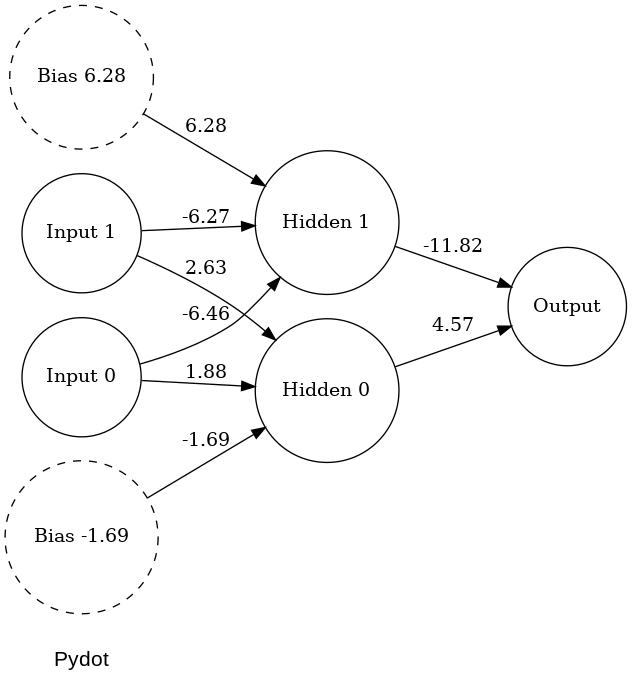

In [5]:
import pydot
from IPython.display import Image, display

# Create a new graph
graph = pydot.Dot(graph_type='digraph', rankdir='LR')  # 'LR' to lay out nodes from left to right

# Add a title as an invisible node
title = pydot.Node("title", label="Pydot", shape="plaintext", fontsize="16", fontname="Arial", color="black")
graph.add_node(title)

# Define node lists for layers
input_nodes = [f"Input {i}" for i in range(model.fc1.in_features)]
hidden_nodes = [f"Hidden {i}" for i in range(model.fc1.out_features)]
output_node = "Output"

# Add input layer nodes
for node in input_nodes:
    graph.add_node(pydot.Node(node, shape='circle'))

# Add hidden layer nodes
for node in hidden_nodes:
    graph.add_node(pydot.Node(node, shape='circle'))

# Add output node
graph.add_node(pydot.Node(output_node, shape='circle'))

# Add edges between input and hidden layer
for i, input_node in enumerate(input_nodes):
    for j, hidden_node in enumerate(hidden_nodes):
        weight = model.fc1.weight[j, i].item()
        edge_label = f"{weight:.2f}"
        graph.add_edge(pydot.Edge(input_node, hidden_node, label=edge_label))

# Add edges between hidden layer and output layer
for i, hidden_node in enumerate(hidden_nodes):
    weight = model.fc2.weight[0, i].item()
    edge_label = f"{weight:.2f}"
    graph.add_edge(pydot.Edge(hidden_node, output_node, label=edge_label))

# Add bias nodes and edges
for i, hidden_node in enumerate(hidden_nodes):
    bias_value = model.fc1.bias[i].item()
    bias_node_id = f"Bias_Hidden_{i}"
    graph.add_node(pydot.Node(bias_node_id, shape='circle', label=f"Bias {bias_value:.2f}", style='dashed'))
    graph.add_edge(pydot.Edge(bias_node_id, hidden_node, label=f"{bias_value:.2f}"))

# Save the graph as a PNG image
graph.write_png('network_with_title.png')

# Display the image
display(Image('network_with_title.png'))

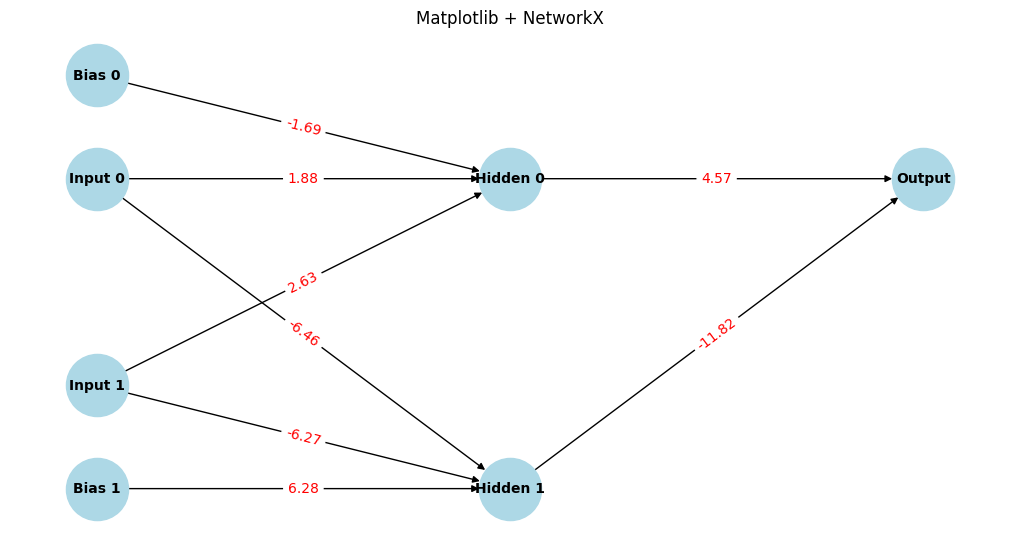

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes with positions for Input, Hidden, and Output layers
positions = {}
input_size = model.fc1.in_features
hidden_size = model.fc1.out_features
output_size = model.fc2.out_features

# Add Input nodes
for i in range(input_size):
    node_id = f"Input {i}"
    G.add_node(node_id)
    positions[node_id] = (0, -i)

# Add Hidden nodes
for i in range(hidden_size):
    node_id = f"Hidden {i}"
    G.add_node(node_id)
    positions[node_id] = (1, -i * 1.5)  # Adjust vertical spacing

# Add Output node
output_node_id = "Output"
G.add_node(output_node_id)
positions[output_node_id] = (2, 0)

# Add Bias nodes (one for each hidden node)
for i in range(hidden_size):
    bias_node_id = f"Bias {i}"
    G.add_node(bias_node_id)
    positions[bias_node_id] = (0, -i * 2 + 0.5)  # Position bias nodes between input and hidden layers
    G.add_edge(bias_node_id, f"Hidden {i}", weight=model.fc1.bias[i].item())  # Connect bias to hidden node

# Add connections between Input and Hidden layers
for input_node in range(input_size):
    for hidden_node in range(hidden_size):
        weight = model.fc1.weight[hidden_node, input_node].item()
        G.add_edge(f"Input {input_node}", f"Hidden {hidden_node}", weight=weight)

# Add connections between Hidden and Output layers
for hidden_node in range(hidden_size):
    weight = model.fc2.weight[0, hidden_node].item()
    G.add_edge(f"Hidden {hidden_node}", output_node_id, weight=weight)

# Draw the network
plt.figure(figsize=(10, 5))
nx.draw(G, positions, with_labels=True, node_size=2000, node_color="lightblue", font_size=10, font_weight="bold")

# Draw edge labels
edge_labels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, positions, edge_labels=edge_labels, font_color='red')

plt.title("Matplotlib + NetworkX")
plt.show()


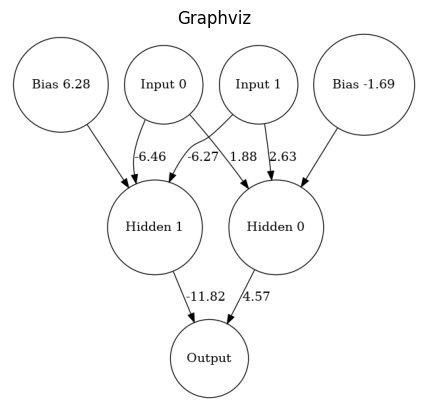

In [7]:
from graphviz import Digraph

# Create a new directed graph
dot = Digraph()

# Add Input nodes
for i in range(input_size):
    node_id = f"Input {i}"
    dot.node(node_id, node_id, shape="circle")

# Add Hidden nodes
for i in range(hidden_size):
    node_id = f"Hidden {i}"
    dot.node(node_id, node_id, shape="circle")

# Add Output node
dot.node("Output", "Output", shape="circle")

# Add Bias nodes for the Hidden Layer
for i in range(hidden_size):
    bias_node_id = f"Bias Hidden {i}"
    dot.node(bias_node_id, label=f"Bias {model.fc1.bias[i].item():.2f}", shape="circle")
    dot.edge(bias_node_id, f"Hidden {i}")  # Connect bias to hidden node

# Add connections between Input and Hidden layers
for input_node in range(input_size):
    for hidden_node in range(hidden_size):
        weight = model.fc1.weight[hidden_node, input_node].item()
        dot.edge(f"Input {input_node}", f"Hidden {hidden_node}", label=f"{weight:.2f}")

# Add connections between Hidden and Output layers
for hidden_node in range(hidden_size):
    weight = model.fc2.weight[0, hidden_node].item()
    dot.edge(f"Hidden {hidden_node}", "Output", label=f"{weight:.2f}")

# Render the graph as a PNG and open it
dot.render('neural_network', format='png', view=False)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load and display the image
img = mpimg.imread('neural_network.png') 
plt.title("Graphviz")
plt.imshow(img)
plt.axis('off')  
plt.show()

In [14]:
from bokeh.io import output_file, show
from bokeh.plotting import figure
from bokeh.models import GraphRenderer, StaticLayoutProvider, Circle, MultiLine
import networkx as nx

# Create a networkx graph
G = nx.DiGraph()

# Extract input, hidden, and output sizes from your model
input_size = model.fc1.in_features
hidden_size = model.fc1.out_features
output_size = model.fc2.out_features  # Assuming a single output node

# Create node labels
input_nodes = [f"Input {i}" for i in range(input_size)]
hidden_nodes = [f"Hidden {i}" for i in range(hidden_size)]
output_node = "Output"

# Add nodes to the graph
for node in input_nodes + hidden_nodes + [output_node]:
    G.add_node(node)

# Add edges between input and hidden layers with weights
for i in range(input_size):
    for j in range(hidden_size):
        weight = model.fc1.weight[j, i].item()
        G.add_edge(f"Input {i}", f"Hidden {j}", weight=weight)

# Add edges between hidden and output layers with weights
for j in range(hidden_size):
    weight = model.fc2.weight[0, j].item()
    G.add_edge(f"Hidden {j}", output_node, weight=weight)

# Create the plot
plot = figure(title="Neural Network Visualization", x_range=(-1, 3), y_range=(-hidden_size, 1),
              tools="", toolbar_location=None)

graph_renderer = GraphRenderer()

# Nodes data
node_indices = list(G.nodes())
graph_renderer.node_renderer.data_source.data = dict(index=node_indices)
graph_renderer.node_renderer.glyph = Circle(radius=0.1, fill_color="skyblue")

# Edges data
start_indices = [node_indices.index(edge[0]) for edge in G.edges()]
end_indices = [node_indices.index(edge[1]) for edge in G.edges()]
edge_weights = [G.edges[edge]['weight'] for edge in G.edges()]
graph_renderer.edge_renderer.data_source.data = dict(start=start_indices, end=end_indices, line_width=edge_weights)

# Customize the edge appearance based on the weight
graph_renderer.edge_renderer.glyph = MultiLine(line_color="black", line_alpha=0.8, line_width='line_width')

# Layout: manually define positions
positions = {}
for i, node in enumerate(input_nodes):
    positions[node] = (0, -i)
for i, node in enumerate(hidden_nodes):
    positions[node] = (1, -i)
positions[output_node] = (2, -hidden_size // 2)

graph_renderer.layout_provider = StaticLayoutProvider(graph_layout=positions)

# Add the renderer to the plot
plot.renderers.append(graph_renderer)

output_file("network.html")
show(plot)

In [ ]:
# Other Approaches

TensorBoard for TensorFlow/PyTorch models:

    If you're working with TensorFlow or PyTorch, TensorBoard offers a built-in tool for visualizing neural networks. You can export your model's graph and view it in a highly interactive interface.

    Pros: TensorBoard provides a clean and interactive visualization. It's especially useful for complex models where you want to trace tensor operations.

    Cons: This might be overkill for very simple models or for situations where you want a highly customized static visualization

4. D3.js for Web-Based Visualizations:

    For ultimate customization and interactivity, D3.js (a JavaScript library) can be used. It allows you to create dynamic, interactive visualizations that run in a web browser.

    Pros: Unparalleled control over the visualization. Perfect for web applications.

    Cons: Requires knowledge of JavaScript and web technologies.

5. Gephi for Visual Analysis:

    Gephi is a powerful network analysis tool that can be used to visualize and analyze complex networks. While it’s more geared toward large-scale network analysis, it can be adapted for neural network visualization.

    Pros: Powerful analysis tools and a wide range of visualization options.

    Cons: Desktop-based and might be overkill for simple neural networks